# Calibration Check on Pre-Vaccine Stochastic Fit

Calibration is done on a pre-vaccine time series starting in 1950 because reporting increased at that time
but pre-vaccine dynamics allow us to fit the non-vaccine parameters while maintaining the primary drivers
of the epidemic at this time. The full fitting approach is to use a multistart screen for reasonable parameter ranges,
IF2 to fit the model, and then repeated high particle runs as casual a validation of the calibration fit.

We check whether IF2 converged and how noisy/identifiable the fitted parameters are.

1. Parameter paths through the IF2 trace
2. Log-likelihood trace vs. IF2 population ESS
3. Cross-parameter correlations and identifiability at the chosen iteration
4. Posterior-predictive check on simulated vs observed cases over the scored window
5. Per step particle filter ESS
6. Spin-up sensitivity
7. Repeated high- article runs with log-likelihood distribution + extinction frequency
8. Log likelihood slice across the most correlated parameter pair

In [ ]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import src.calibration.calibration_metrics as diag
from src.data import data
from src.model import particle_filter, observation_model, stochastic_model, initial_state_prior
from scripts.run_stochastic_calibration import build_fixed_parameters, restrict_date_range, _shift_date_str
from src.utils import load_config

config = load_config('config.yaml')

RESULT_PATH = Path(config['paths']['data_processed_dir']) / 'stochastic_calibration_result.json'
result = diag.load_result(RESULT_PATH)
d = result['if2_diagnostics']

theta_hat is the best-seen IF2 iteration by log-likelihood, not the last iteration's
filtering mean (see IF2Result.theta_hat in calibration.py). theta_hat_last_iteration
is stored separately for comparison.

In [12]:
n_iter, best_it = d['n_iterations'], d['best_iteration']

print(f"theta_hat best seen iteration {best_it + 1}/{n_iter}: {result['theta_hat']}")
print(f"best iteration log-likelihood: {d['log_likelihood_trace'][best_it]:.2f}")
print(f"final iteration log-likelihood: {d['log_likelihood_trace'][-1]:.2f}")

theta_hat (best-seen iteration 7/10): {'beta_0': 405.89643145883554, 'beta_1': 0.47149369650689227, 'phi': 6.135049485771042, 'rho': 0.2623522892227249, 'phi_obs': 1.2693077322532489, 'seed_fraction': 5.560594956498862e-05}
best-iteration log-likelihood: -5449.82
final-iteration log-likelihood: -5680.50


## Parameter paths through the IF2 trace

Per iteration, the weighted mean and weighted SD of the perturbed particle cloud for each
free parameter. Convergence looks like the mean settling and the cloud spread shrinking as the cooling schedule contracts the
perturbation SD. A mean that keeps moving, or a band that stays wide late in the run,
means the perturbation isn't shrinking fast enough relative to how noisy the particle-filter
likelihood is at if2_n_particles.

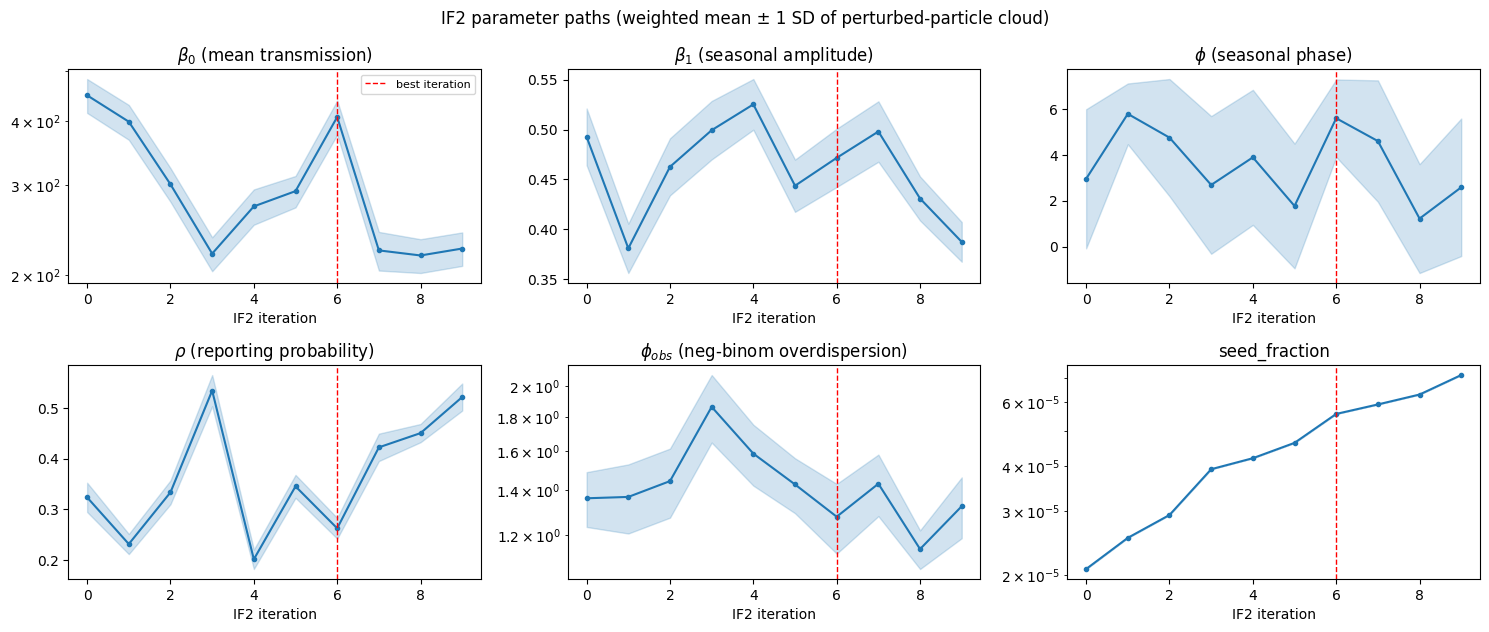

In [3]:
fig = diag.plot_parameter_paths(result)
plt.show()

Seasonal amplitude and over dispersion seem to have relatively settled. Mean transmission sees the tightest standard deviation at the best iteration as does the seasonal phase. The reporting probability and seed fraction are the most concerning as they do not appear to settle. More iterations of IF2 or more particles would likely prove to settle these parameters.

## Log-likelihood trace vs. IF2 population ESS

Shows the IF2 log-likelihood trace alongside the sequential
particle ESS (ESS/N) at every observation interval within every iteration. If population
ESS collapses toward a small number of particles at the same iterations where
log likelihood degrades, a handful of perturbed thetas are dominating the weighted mean.
Evidence for more IF2 particles, not more iterations.

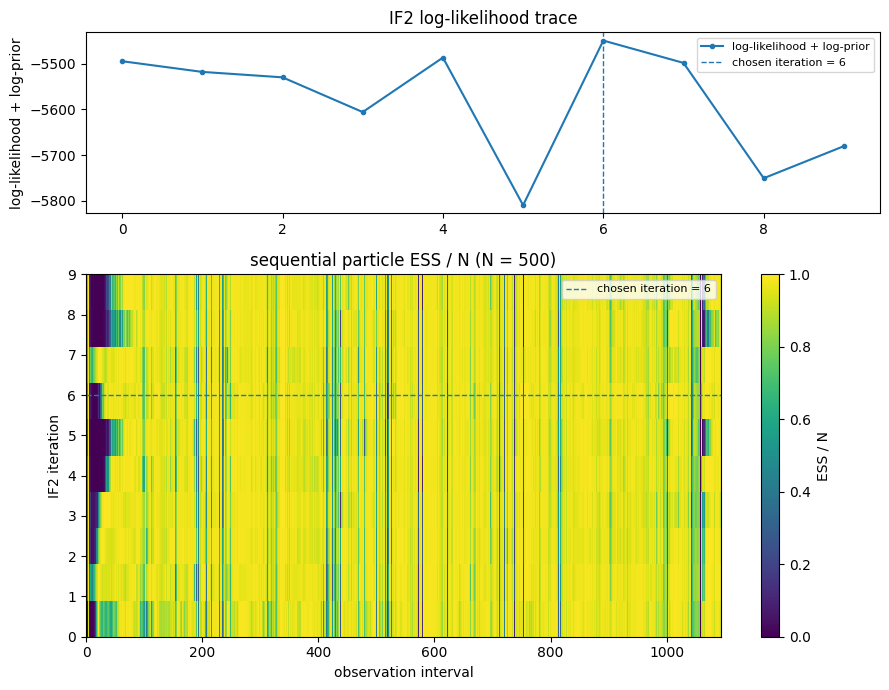

In [4]:
fig = diag.plot_loglik_and_ess_trace(result)
plt.show()

Iterations 5 and 9 see the most extinction in the ESS and the log likelihood drops accordingly. Overall this approach displays significantly less degeneracy than previous iterations though even the selected iteration has some extinction early on. The particle cloud did not collapse

## Parameter correlations at the chosen iteration

Computes the weighted Pearson correlation between free
parameters using the best-seen iterations perturbed particle cloud and its resampling
weights. This is the cloud whose correlations are most relevant to theta_hat's uncertainty
since its the iteration closest to the convergence IF2 actually reached. Strong
correlations ($|r| \geq 0.7$) flag a ridge in the likelihood surface rather than a clean peak, meaning
those parameters trade off against each other and aren't independently identified by this
fit window's data.

,beta_0,beta_1,phi,rho,phi_obs,seed_fraction
beta_0,1.00,0.00,0.04,-0.05,-0.11,-0.00
beta_1,0.00,1.00,-0.20,0.28,0.17,0.00
phi,0.04,-0.20,1.00,-0.13,-0.11,-0.00
rho,-0.05,0.28,-0.13,1.00,-0.03,0.00
phi_obs,-0.11,0.17,-0.11,-0.03,1.00,-0.00
seed_fraction,-0.00,0.00,-0.00,0.00,-0.00,1.00


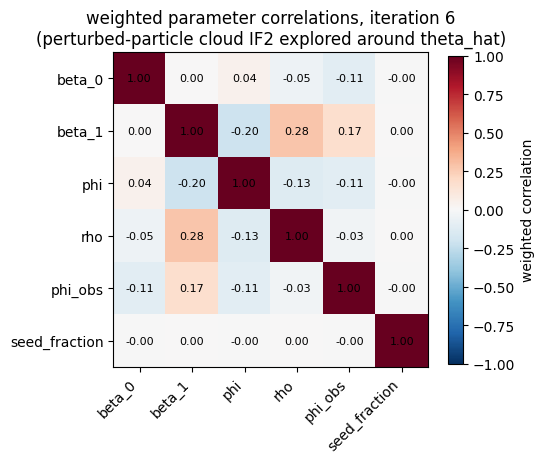

In [5]:
corr = diag.weighted_correlation_matrix(result)
display(corr.style.background_gradient(cmap='RdBu_r', vmin=-1, vmax=1).format('{:.2f}'))

fig = diag.plot_parameter_correlations(result)
plt.show()

No pairs exceed a correlation of $.28$, which is far below the typical threshold of $.7$ for concern. Note the largest correlation is between rho and beta 1

## Posterior predictive check

Forward trajectories at theta_hat from the same initial-state
prior the fit used, over the same fit window, and compares the simulated reported-case
distribution against the real data actually scored.

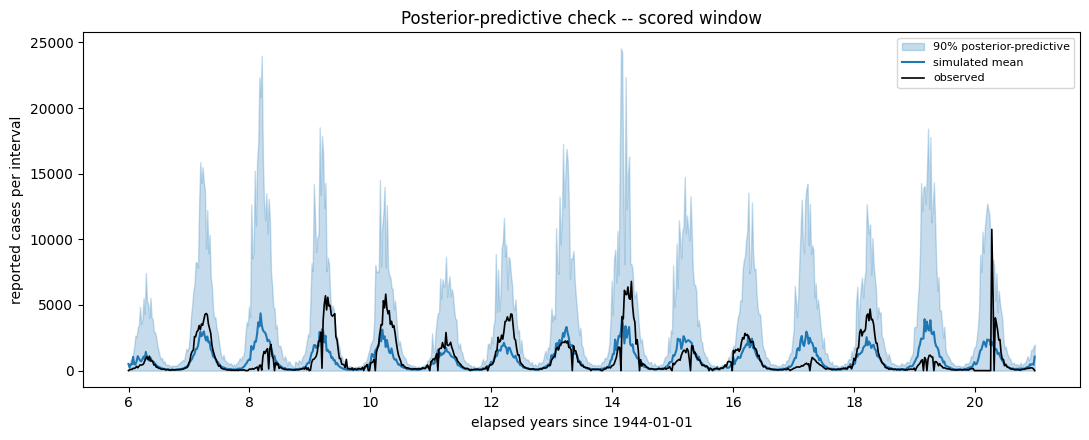

90% interval coverage on scored window: 99.4% (target ~90% if well-calibrated)


In [6]:
N_REPLICATES = 200
SEED = 0

start, end = result['fit_window']['start'], result['fit_window']['end']
spin_up_years = result.get('spin_up_years', 0.0)
sim_start = _shift_date_str(start, -spin_up_years) if spin_up_years > 0 else start

series = data.load_processed_series()
fit_series = restrict_date_range(series, sim_start, end)
observed_times = data.series_to_elapsed_years(fit_series)
observed_case_counts = fit_series['case_count'].to_numpy(dtype=float)
fit_window_start_year = float(sim_start.split('-')[0])

theta_hat = result['theta_hat']
fixed_parameters = build_fixed_parameters(fit_window_start_year)

parameters = {
    'beta_0': theta_hat['beta_0'],
    'beta_1': theta_hat['beta_1'],
    'phi': theta_hat['phi'],
    'gamma': fixed_parameters['gamma'],
    'sigma': fixed_parameters['sigma'],
    'maternal_waning_rate': fixed_parameters['maternal_waning_rate'],
    'birth_rate': particle_filter._wrap_calendar_rate(fixed_parameters['birth_rate'], fit_window_start_year),
    'death_rate': particle_filter._wrap_calendar_rate(fixed_parameters['death_rate'], fit_window_start_year),
    'vaccination_rates': fixed_parameters['vaccination_rates'],
    'contact_matrix': fixed_parameters['contact_matrix'],
}

rng = np.random.default_rng(SEED)
ic_draws = initial_state_prior.sample_initial_states(
    fit_window_start_year=fit_window_start_year,
    seed_fraction=theta_hat['seed_fraction'],
    n_particles=N_REPLICATES,
    rng=rng,
)
particle_states = [
    stochastic_model.make_initial_state(ic['M0'], ic['S0'], ic['E0'], ic['I0'], ic['R0'], t0=observed_times[0])
    for ic in ic_draws
]
cloud = stochastic_model.StochasticParticleCloud.from_states(particle_states)

T = len(observed_times)
simulated_cases = np.zeros((N_REPLICATES, T - 1))
for k in range(1, T):
    duration = float(observed_times[k] - observed_times[k - 1])
    cloud, incidences = stochastic_model.simulate_interval_batch(cloud, duration, parameters, rng, dt=None)
    mu = theta_hat['rho'] * incidences.sum(axis=1)
    simulated_cases[:, k - 1] = observation_model.negbin_rvs(mu, theta_hat['phi_obs'], rng)

scored_mask = fit_series['period_start'].to_numpy()[1:] >= np.datetime64(start)
plot_times = observed_times[1:][scored_mask]
observed_scored = observed_case_counts[1:][scored_mask]
simulated_scored = simulated_cases[:, scored_mask]

q05, q95 = np.quantile(simulated_scored, [0.05, 0.95], axis=0)
q_mean = simulated_scored.mean(axis=0)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.fill_between(plot_times, q05, q95, alpha=0.25, color='C0', label='90% posterior-predictive')
ax.plot(plot_times, q_mean, color='C0', lw=1.5, label='simulated mean')
ax.plot(plot_times, observed_scored, color='k', lw=1.2, label='observed')
ax.set_xlabel(f'elapsed years since {sim_start}')
ax.set_ylabel('reported cases per interval')
ax.set_title('Posterior-predictive check -- scored window')
ax.legend(loc='upper right', fontsize=8)
fig.tight_layout()
plt.show()

coverage_90 = np.mean((observed_scored >= q05) & (observed_scored <= q95))
print(f'90% interval coverage on scored window: {coverage_90:.1%}, target ~90% if well-calibrated')

Visually, the mean tracks the true reported cases relatively well. While it tends to have more consistent and overestimate the low peak years while underestimating the high peak years, the general shape does match the shape of the calibration data.

Empirically, the 90% interval covers the vast majority of the observed data, indicating overestimate and higher than desired variance.

## Per step particle filter ESS at $\hat\theta$

A single particle-filter run at theta_hat with per-step ESS plotted alongside observed case counts. ESS collapsing early
and partially recovering is consistent with small-seed fadeout because the seed_fraction is too small
relative to population size. ESS staying uniformly low across the series is more
consistent with observation overdispersion as a result of phi_obs being too small.

log-likelihood (single run, N=500): -6126.98
resampling events: 36 / 783 observation times


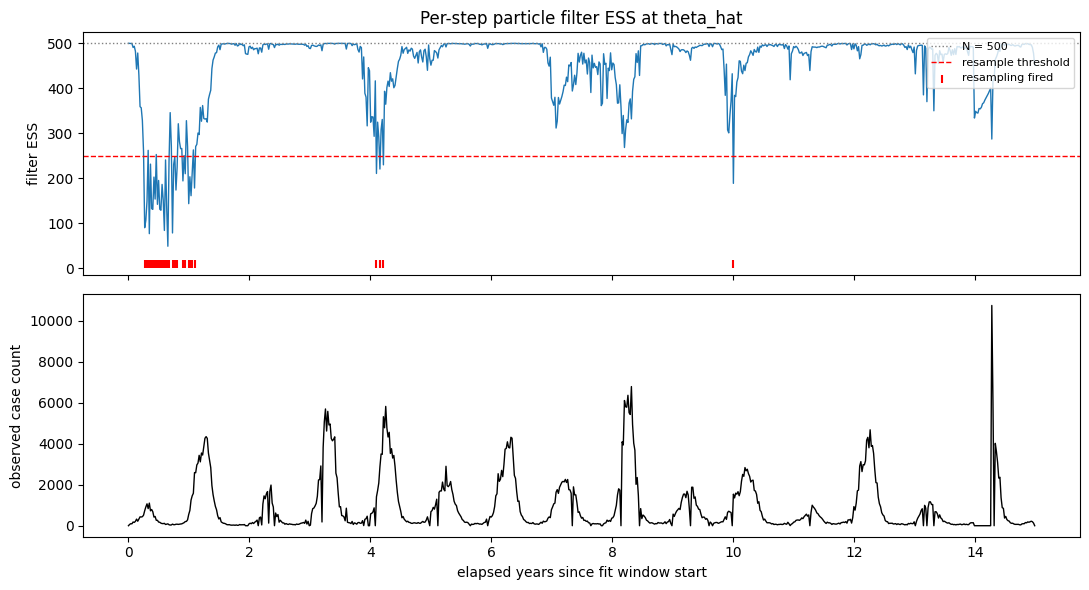

mean ESS/N, first 20% of series:    77.97%
mean ESS/N, remaining 80% of series: 93.68%


In [7]:
N_DIAGNOSTIC_PARTICLES = 500

start, end = result['fit_window']['start'], result['fit_window']['end']
fit_window_start_year = float(start.split('-')[0])

series = data.load_processed_series()
fit_series = restrict_date_range(series, start, end)
observed_times = data.series_to_elapsed_years(fit_series)
observed_case_counts = fit_series['case_count'].to_numpy(dtype=float)
fixed_parameters = build_fixed_parameters(fit_window_start_year)

rng = np.random.default_rng(2026)
pf_result = particle_filter.run_particle_filter(
    theta=result['theta_hat'],
    observed_times=observed_times,
    observed_case_counts=observed_case_counts,
    fixed_parameters=fixed_parameters,
    n_particles=N_DIAGNOSTIC_PARTICLES,
    rng=rng,
    fit_window_start_year=fit_window_start_year,
)

print(f'log-likelihood (single run, N={N_DIAGNOSTIC_PARTICLES}): {pf_result.log_likelihood:.2f}')
print(f'resampling events: {pf_result.resampled_history.sum()} / {len(observed_times)} observation times')

resample_threshold = config['calibration']['particle_filter_ess_resample_fraction'] * N_DIAGNOSTIC_PARTICLES

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
ax1.plot(observed_times, pf_result.ess_history, color='C0', lw=1)
ax1.axhline(N_DIAGNOSTIC_PARTICLES, color='gray', ls=':', lw=1, label=f'N = {N_DIAGNOSTIC_PARTICLES}')
ax1.axhline(resample_threshold, color='red', ls='--', lw=1, label='resample threshold')
resample_times = observed_times[pf_result.resampled_history]
ax1.scatter(resample_times, np.full_like(resample_times, N_DIAGNOSTIC_PARTICLES * 0.02),
            marker='|', color='red', s=40, label='resampling fired')
ax1.set_ylabel('filter ESS')
ax1.legend(fontsize=8, loc='upper right')
ax1.set_title('Per-step particle filter ESS at theta_hat')

ax2.plot(observed_times[:len(observed_case_counts)], observed_case_counts, color='k', lw=1)
ax2.set_ylabel('observed case count')
ax2.set_xlabel('elapsed years since fit window start')
fig.tight_layout()
plt.show()

n_early = len(observed_times) // 5
early_ess_frac = pf_result.ess_history[:n_early].mean() / N_DIAGNOSTIC_PARTICLES
late_ess_frac = pf_result.ess_history[n_early:].mean() / N_DIAGNOSTIC_PARTICLES
print(f'mean ESS/N, first 20% of series:    {early_ess_frac:.2%}')
print(f'mean ESS/N, remaining 80% of series: {late_ess_frac:.2%}')

Low ESS periods occur primarily at the beginning of the simulation, and do not tend to line up with case troughs. Evidence for introducing spin up to push extinction out of scoring window since it is concentrated at the start of the simulation

## Spin-up sensitivity

Reruns the Section 5 diagnostic with SPINUP_YEARS of additional real data simulated
before the scored window, so the seed_fraction transient has time to run in before
reaching the region that's actually scored. Same theta_hat, same real Tycho case counts
for the earlier years — only the simulation start date changes. The original scored window
is shaded; compare ESS/N and resample-threshold breaches within that shaded region against
Section 5's numbers directly.

log-likelihood over spin-up + scored window: -8630.94


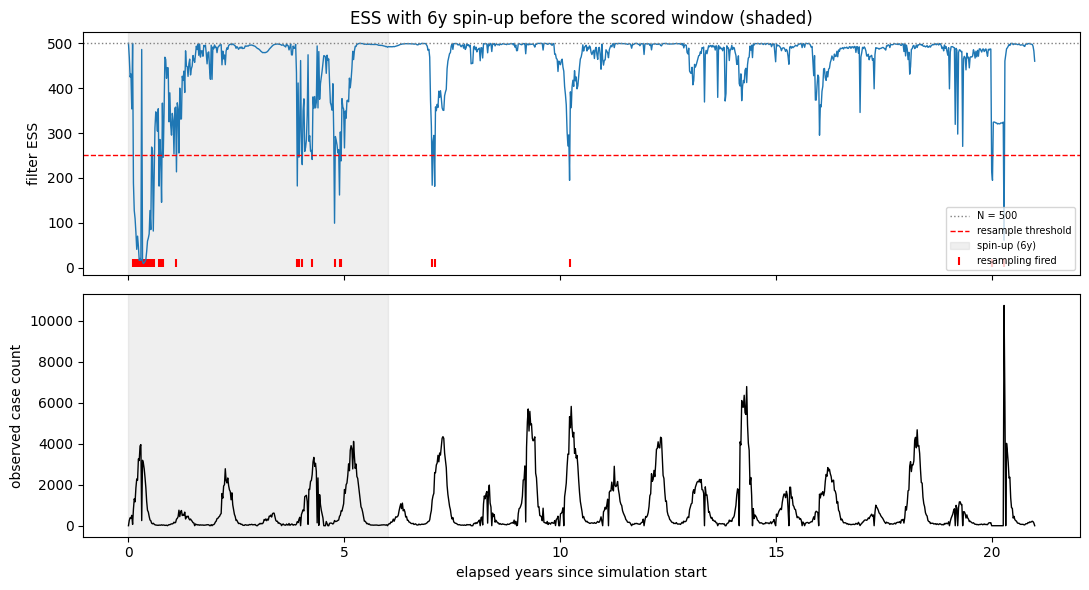

with spin-up, mean ESS/N in the original scored window: 94.77%
resample-threshold breaches in the scored window: 6 / 782 steps


In [8]:
SPINUP_YEARS = 6

score_start, score_end = result['fit_window']['start'], result['fit_window']['end']
spinup_start = f'{int(score_start.split('-')[0]) - SPINUP_YEARS}-01-01'
fit_window_start_year = float(spinup_start.split('-')[0])
fixed_parameters = build_fixed_parameters(fit_window_start_year)

series = data.load_processed_series()
fit_series = restrict_date_range(series, spinup_start, score_end)
observed_times = data.series_to_elapsed_years(fit_series)
observed_case_counts = fit_series['case_count'].to_numpy(dtype=float)
score_start_elapsed = float(score_start.split('-')[0]) - fit_window_start_year

rng = np.random.default_rng(2026)
pf_result = particle_filter.run_particle_filter(
    theta=result['theta_hat'],
    observed_times=observed_times,
    observed_case_counts=observed_case_counts,
    fixed_parameters=fixed_parameters,
    n_particles=N_DIAGNOSTIC_PARTICLES,
    rng=rng,
    fit_window_start_year=fit_window_start_year,
)
print(f'log-likelihood over spin-up + scored window: {pf_result.log_likelihood:.2f}')

resample_threshold = config['calibration']['particle_filter_ess_resample_fraction'] * N_DIAGNOSTIC_PARTICLES

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
ax1.plot(observed_times, pf_result.ess_history, color='C0', lw=1)
ax1.axhline(N_DIAGNOSTIC_PARTICLES, color='gray', ls=':', lw=1, label=f'N = {N_DIAGNOSTIC_PARTICLES}')
ax1.axhline(resample_threshold, color='red', ls='--', lw=1, label='resample threshold')
ax1.axvspan(0, score_start_elapsed, color='gray', alpha=0.12, label=f'spin-up ({SPINUP_YEARS}y)')
resample_times = observed_times[pf_result.resampled_history]
ax1.scatter(resample_times, np.full_like(resample_times, N_DIAGNOSTIC_PARTICLES * 0.02),
            marker='|', color='red', s=40, label='resampling fired')
ax1.set_ylabel('filter ESS')
ax1.legend(fontsize=7, loc='lower right')
ax1.set_title(f'ESS with {SPINUP_YEARS}y spin-up before the scored window (shaded)')

ax2.plot(observed_times[:len(observed_case_counts)], observed_case_counts, color='k', lw=1)
ax2.axvspan(0, score_start_elapsed, color='gray', alpha=0.12)
ax2.set_ylabel('observed case count')
ax2.set_xlabel('elapsed years since simulation start')
fig.tight_layout()
plt.show()

scored_mask = observed_times >= score_start_elapsed
scored_ess_frac = pf_result.ess_history[scored_mask].mean() / N_DIAGNOSTIC_PARTICLES
n_breaches = (pf_result.ess_history[scored_mask] < resample_threshold).sum()
print(f'with spin-up, mean ESS/N in the original scored window: {scored_ess_frac:.2%}')
print(f'resample-threshold breaches in the scored window: {n_breaches} / {scored_mask.sum()} steps')

Adding spin up significantly improves low ESS rate during the scored window, lining up exactly with the expectation from the no spin up run

## Repeated high-particle runs at theta_hat

final_likelihood_evaluation (run as part of calibration) used only 5 replicates.
repeated_high_particle_runs reruns with more replicates purely for diagnostics, for a
steadier read on both the log-likelihood noise floor and the extinction frequency at
theta_hat — relevant for forward simulation later, since a high extinction frequency
means a lot of all-zero forward trajectories.

[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.
[Parallel(n_jobs=5)]: Done   2 out of   5 | elapsed:  1.7min remaining:  2.5min


{'n_particles': 2000, 'n_replicates': 5, 'n_extinct': 0, 'extinction_frequency': 0.0, 'log_likelihood_mean': -6038.832985793476, 'log_likelihood_se': 14.293048413002843}


[Parallel(n_jobs=5)]: Done   5 out of   5 | elapsed:  1.7min finished


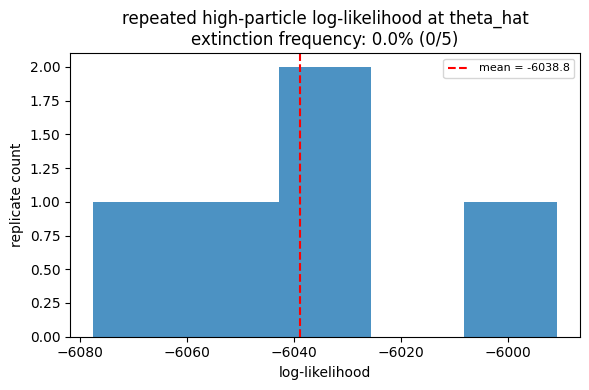

In [10]:
N_REPLICATES = 5

start, end = result['fit_window']['start'], result['fit_window']['end']
series = data.load_processed_series()
fit_series = restrict_date_range(series, start, end)
observed_times = data.series_to_elapsed_years(fit_series)
observed_case_counts = fit_series['case_count'].to_numpy(dtype=float)
fit_window_start_year = float(start.split('-')[0])
fixed_parameters = build_fixed_parameters(fit_window_start_year)

rep_df, rep_summary = diag.repeated_high_particle_runs(
    theta_hat=result['theta_hat'],
    observed_times=observed_times,
    observed_case_counts=observed_case_counts,
    fixed_parameters=fixed_parameters,
    fit_window_start_year=fit_window_start_year,
    n_particles=config['calibration']['particle_filter_n_particles_final'],
    n_replicates=N_REPLICATES,
)
print(rep_summary)

fig = diag.plot_replicate_loglik_distribution(rep_df, rep_summary)
plt.show()

High particle log likelihood is extremely consistent across runs with low standard deviation especially relative to magnitude. No high particle runs experience extinction, evidence of stable model performance

## Log-likelihood slice across a correlated parameter pair

A 2-D grid of particle-filter log-likelihood evaluations around theta_hat, varying the
pair of free parameters with the strongest correlation and holding all
others fixed. A ridge along the correlation's diagonal is visual evidence of non-identifiability.

mean per-gridpoint log-lik SD: 18.00 (bump SLICE_REPLICATES if this is large relative to the range of slice_loglik)


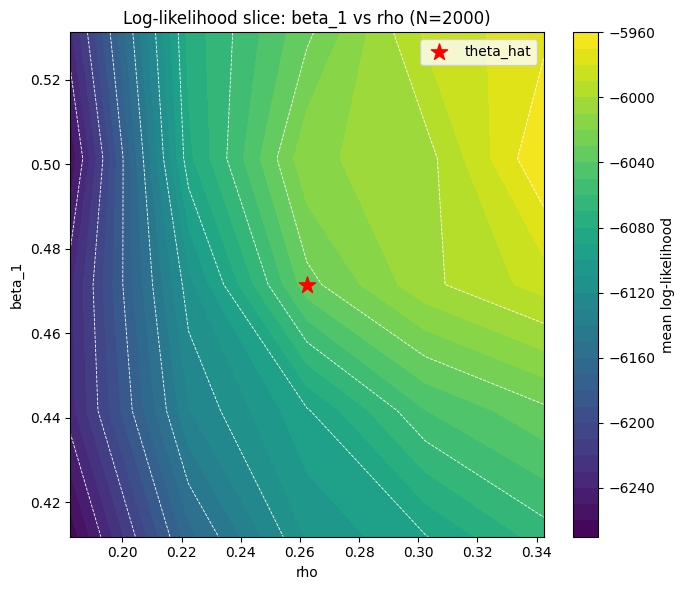

In [11]:
PARAM_A, PARAM_B = 'beta_1', 'rho' 
GRID_N = 5
GRID_HALFWIDTH_SD = 3.0
SLICE_REPLICATES = 3
N_INNER_PARTICLES = config['calibration']['particle_filter_n_particles_final']

theta_hat = result['theta_hat']
param_order = d['free_param_order']
final_theta_particles = np.asarray(d['particle_theta_trace'])[-1]
final_weights = np.asarray(d['particle_weight_trace'])[-1]
final_weights = final_weights / final_weights.sum()
param_idx = {name: i for i, name in enumerate(param_order)}

def weighted_sd(param_name):
    vals = final_theta_particles[:, param_idx[param_name]]
    mean = np.average(vals, weights=final_weights)
    return float(np.sqrt(np.average((vals - mean) ** 2, weights=final_weights)))

sd_a, sd_b = weighted_sd(PARAM_A), weighted_sd(PARAM_B)
center_a, center_b = theta_hat[PARAM_A], theta_hat[PARAM_B]

grid_a = np.linspace(center_a - GRID_HALFWIDTH_SD * sd_a, center_a + GRID_HALFWIDTH_SD * sd_a, GRID_N)
grid_b = np.linspace(center_b - GRID_HALFWIDTH_SD * sd_b, center_b + GRID_HALFWIDTH_SD * sd_b, GRID_N)

for param_name, grid in ((PARAM_A, grid_a), (PARAM_B, grid_b)):
    bounds = config['calibration']['parameter_bounds'].get(param_name)
    if bounds:
        lo, hi = bounds
        grid[:] = np.clip(grid, lo if lo is not None else -np.inf, hi if hi is not None else np.inf)

grid_thetas = []
for a_val in grid_a:
    for b_val in grid_b:
        theta_grid = dict(theta_hat)
        theta_grid[PARAM_A] = float(a_val)
        theta_grid[PARAM_B] = float(b_val)
        grid_thetas.extend([theta_grid] * SLICE_REPLICATES)

master_rng = np.random.default_rng(90210)
batch_result = particle_filter.run_particle_filter_batch_parallel(
    thetas=grid_thetas,
    observed_times=observed_times,
    observed_case_counts=observed_case_counts,
    fixed_parameters=fixed_parameters,
    n_inner_particles=N_INNER_PARTICLES,
    rng=master_rng,
    fit_window_start_year=fit_window_start_year,
)

ll = batch_result.log_likelihood.reshape(GRID_N, GRID_N, SLICE_REPLICATES)
slice_loglik = np.nanmean(ll, axis=2)
slice_loglik_sd = np.nanstd(ll, axis=2)
print(f'mean per-gridpoint log-lik SD: {np.nanmean(slice_loglik_sd):.2f}')

fig, ax = plt.subplots(figsize=(7, 6))
cs = ax.contourf(grid_b, grid_a, slice_loglik, levels=30, cmap='viridis')
ax.contour(grid_b, grid_a, slice_loglik, levels=10, colors='white', linewidths=0.6)
ax.scatter([center_b], [center_a], color='red', marker='*', s=150, label='theta_hat', zorder=5)
ax.set_xlabel(PARAM_B)
ax.set_ylabel(PARAM_A)
ax.set_title(f'Log-likelihood slice: {PARAM_A} vs {PARAM_B} (N={N_INNER_PARTICLES})')
fig.colorbar(cs, ax=ax, label='mean log-likelihood')
ax.legend()
fig.tight_layout()
plt.show()

The log-likelihood is smooth and unimodal in the slice, increasing toward higher rho and beta_1. $\hat \theta$ does not sit at the slice maximum, which may reflect that it is a joint optimum, and the parameter directions do general match the trends from the overall parameter evolution through the fitting process.